# RPZ = Jupiter, Saturno, Urano

In [19]:
RPZ = 'Jupiter','Saturno' ,'Urano'
RPZ

('Jupiter', 'Saturno', 'Urano')

In [20]:
Jupiter = 'José Russo'
Saturno = 'Henrique Carmona'
Urano = 'Dinis Borges'
Jupiter
Saturno
Urano

'José Russo'

'Henrique Carmona'

'Dinis Borges'

# 0 - Imports

In this section, we decided to add some extra imports besides Pandas.
Here is a quick reasoning of why the following libraries where imported.

We decided to import Pandas since it is one of the libraries that we are more familliar with and it is great to handle patient records which is the case.

Numpy was imported since it is a great support for mathmatical and numeriacal operations. Numpy will be used for the calculation of descriptive statistics and to help in missing values and outliers detection.

Regarding matplotlib we imported it so we can generate plots and visual representations of our data, such as histograms, box plots and bar plots.

Finally seaborn was imported as a add-on to matplotlib so we can better visualize the information contained in the graphs as well as make them more pleasant to the eye.

The configuration of the seaborn library was set to darkgrid, as we believe it is easier to visualize than the whitegrid one.

In [21]:
#Libraries Imported

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plot configuration and design
sns.set(style="darkgrid")



# 1 - Options

In [22]:
# General Display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_columns', None)

# 2 - Data Overview

In [23]:
#Load the dataset
dataset_url = 'https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica25/refs/heads/main/Final%20Project/data/train.csv'
df = pd.read_csv(dataset_url)


#Dataset Initial Preview
df.head(3)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0,0
1,0,57,2.0,0,0.0,0.0,0,1,0,250.0,152.5,92.5,32.31,75.0,94.0,0
2,0,47,1.0,0,0.0,0.0,0,0,0,230.0,123.0,71.0,26.98,83.0,73.0,0


In [24]:
# See tail of the dataframe (last 3 rows)
df.tail(3)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3387,0,60,2.0,0,0.0,0.0,0,1,0,298.0,133.0,89.0,25.09,83.0,81.0,0
3388,1,39,2.0,1,10.0,0.0,0,0,0,215.0,102.0,64.5,24.50,68.0,62.0,0
3389,0,35,2.0,0,0.0,0.0,0,0,0,248.0,107.0,73.0,20.64,90.0,80.0,0


In [25]:
# See the exact number of rows and columns on this Dataset. We decided to code a full sentence for aesthetic reasons.However, if we only wanted the values we could just code for:  df.shape
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.shape

Dataset contains 3390 rows and 16 columns.


(3390, 16)

In [26]:
# We want to check the types of variables present in each column

df.dtypes

,0
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


# 3 - Initial Exploration


Since we already inspected the first 3 rows with 'df.head(3)' and confirmed the overall shape with 'df.shape' in point: 2 - Code. We decided to move into the data types and summary statistics to gain a deeper understanding of each feature.

## 3.1 - Check data types and non‐null counts

We ran `df.info()` here because it gives me everything I need in one shot:

- **Index**: the row numbers shown in the output (it doesn’t change the data itself).  
- **Columns**: lists each variable name, like `age`, `glucose`, or `TenYearCHD`.  
- **Non-Null Count**: tells me how many of the 3,390 rows actually have a value in that column (anything below 3,390 means there are missing entries).  
- **Dtype**: shows the data type—`int64` for whole-number fields (like binary flags) and `float64` for decimal measurements (like blood pressure or BMI).

If I ever just want one part of that summary, I can run:

```python
df.columns         # to get the list of column names
df.isnull().sum() # to count missing values per column
df.dtypes          # to check each column’s data type
df.memory_usage()  # to see how much memory each column is using


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3302 non-null   float64
 3   currentSmoker    3390 non-null   int64  
 4   cigsPerDay       3366 non-null   float64
 5   BPMeds           3342 non-null   float64
 6   prevalentStroke  3390 non-null   int64  
 7   prevalentHyp     3390 non-null   int64  
 8   diabetes         3390 non-null   int64  
 9   totChol          3348 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3376 non-null   float64
 13  heartRate        3389 non-null   float64
 14  glucose          3076 non-null   float64
 15  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 423.9 KB


In [28]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,3390.0,0.422714,0.494064,0.00,0.000,0.000,1.00,1.0
age,3390.0,49.522124,8.577177,32.00,42.000,49.000,56.00,70.0
education,3302.0,1.970018,1.014889,1.00,1.000,2.000,3.00,4.0
currentSmoker,3390.0,0.499115,0.500073,0.00,0.000,0.000,1.00,1.0
cigsPerDay,3366.0,9.058526,11.925169,0.00,0.000,0.000,20.00,60.0
BPMeds,3342.0,0.029623,0.169570,0.00,0.000,0.000,0.00,1.0
prevalentStroke,3390.0,0.006195,0.078474,0.00,0.000,0.000,0.00,1.0
prevalentHyp,3390.0,0.313274,0.463893,0.00,0.000,0.000,1.00,1.0
diabetes,3390.0,0.025074,0.156372,0.00,0.000,0.000,0.00,1.0
totChol,3348.0,236.876643,44.761840,107.00,206.000,234.000,263.00,696.0


## 3.2 - Target Variable (CHD) Analysis and Visualization

First of all, to be easier we decided to change the TenYearCHD variable name to just CHD.

In [29]:
df.rename(columns={"TenYearCHD": "CHD"}, inplace=True)

As the main goal of this model is to understand if a person will or will not develop CHD in a 10 years timeline, being that our target variable, we will analyze the CHD distribution carefully.

In [30]:
print(df.columns.tolist())


['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'CHD']


In [31]:
# Distribution of CHD (target variable)
df['CHD'].value_counts()


,count
CHD,
0,2870
1,520


To visualize this distribution in a better way we did a bar plot.

For this we used the code below.


The following piece of code: sns.countplot(...) is basically a function from the Seaborn library, imported previously as sns,to make bar charts that will count the number of ocurrences of each category.


By using data=df we are basically telling the chart to use the data from our dataset, df.

X='CHD' will set the variable present in the x axis. In this case the CHD.

hue='CHD' will basically make the two different variable categories to have a different assigned color. In this case CHD=0 will have one color and CHD=1 will have another.

palette='Set2' defines the color of the plot, being Set2 more soft colors. However, we could choose many other color combinations from the seaborn package.

Lastly, legend=False tells that we don't need any legen on our plot. We though it would be better to not have any legen on this plot, specifically, since it would make the plot more clean and is not necessary to have a legend in this specific case.

<Axes: xlabel='CHD', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Coronary Heart Disease (CHD)')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'Number of Patients')

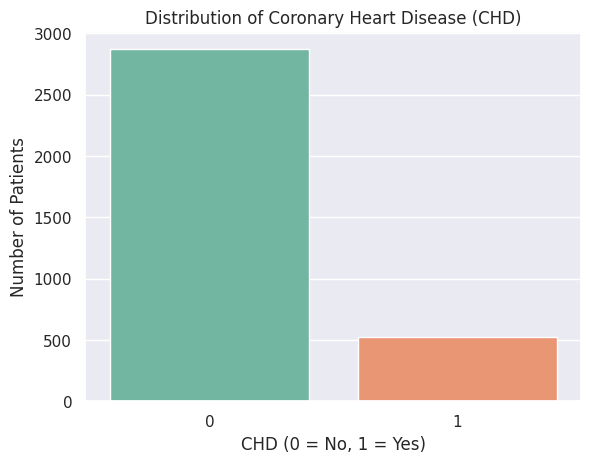

In [32]:
# Bar plot of CHD

sns.countplot(data=df, x='CHD', hue='CHD', palette='Set2', legend=False)
plt.title('Distribution of Coronary Heart Disease (CHD)')
plt.xlabel('CHD (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()


Next we calculated the percentage of patients with and without CHD, after 10 years.

For that we used the following code:

In [33]:
# Calculate percentage breakdown of CHD variable
chd_pct = df['CHD'].value_counts(normalize=True) * 100

# Now print rounded values
print(f"Patients without CHD: {chd_pct[0]:.2f}%")
print(f"Patients with CHD: {chd_pct[1]:.2f}%")



Patients without CHD: 84.66%
Patients with CHD: 15.34%


In the code above we used f"..." to convert the variables into string.

The chd_pct[0] gives the percentage of patients without CHD while the chd_pct[1] gives the percentage of patients with CHD.

Lastly, the :.2f rounds each value to 2 decimal places.

As we can see, the majority of patients in this dataset, 84.66%, did not develop Coronary Heart Disease (CHD) over the 10-year follow-up period. Only 15.34% of patients did develop CHD, indicating a class imbalancee. This is an important consideration for future model development.

# 4 - Missing values analysis

For the missing values, we first used the following code to check how many values were missing for each of the columns (variables).

  - df.isnull()
→ Returns a DataFrame of True/False where True means missing value (NaN)

  - .mean()
→ On a boolean DataFrame, True = 1 and False = 0, so mean() gives you the fraction of missing values per column

  - .sort_values(ascending=False)
→ Sorts the columns from most to least missing

  - [missing_frac > 0]
→ Filters to only the columns that have missing values

In [34]:
df.isnull().sum().sort_values(ascending=False)

,0
glucose,314
education,88
BPMeds,48
totChol,42
cigsPerDay,24
BMI,14
heartRate,1
male,0
prevalentHyp,0
prevalentStroke,0


After this we checked the percentage of missing values in each column.

df.isnull( ) will create a boolean table where every missing value is marked as True.

After that we add .mean( ) at the end. This will basically calculate the mean and since in Phyton True counts as 1, this will give us the fraction of missing values in each column.



In [35]:
# Percentage of missing values per feature

# Missing fraction calculation

missing_frac = df.isnull().mean()

Now that we have the fraction of missing values for each variable, we are going to filter it so it will only display the fractions greater than 0.

In [36]:
# Filter only columns with > 0% missing values

missing_frac_filtered = missing_frac[missing_frac > 0]

We will now convert this into a DataFrame because it will be easier to print and plot in the future.

In [37]:
# Convert to DataFrame

missing_frac_df = missing_frac_filtered.to_frame(name="missing_fraction").sort_values(by="missing_fraction", ascending=False)

Besides that we will also organize it so the columns with the most missing data appear first. We do this by adding .sort_values(by="missing_fraction", ascending=False). In this way, the values will appear in a descending order since ascending=False. For an ascending order of the results we would use ascending=True.


In [38]:

# Convert to DataFrame

missing_frac_df = missing_frac_filtered.to_frame(name="missing_fraction").sort_values(by="missing_fraction", ascending=False)



Finally we display the fractions of filtered missing data in a descending order.

In [39]:
# Display the result
missing_frac_df

,missing_fraction
glucose,0.092625
education,0.025959
BPMeds,0.014159
totChol,0.012389
cigsPerDay,0.007080
BMI,0.004130
heartRate,0.000295


This fractions combined with the total amount of missing values helped us to see to what extent did the missing values impact our sample.


# 5 - Univariate Distributions

In this section, we examine each feature on its own to understand its basic shape, spread, and any irregularities. Univariate analysis helps us:

- Detect skewness and tails- that may require transformations (e.g., log, square‐root)  
- Identify outliers- that could unduly influence our models  
- Measure class balance- in binary or ordinal variables  

We break this down into two parts:

### 5.1 - Continuous Features

1. Histogram Grid: eight continuous features plotted in a 2×4 layout to compare distributions side by side.  
2. Summary Statistics Table: means, medians, standard deviations, and skewness values for each feature—quantifies what we see with our eyes.  
3. Boxplots for Outlier Detection: highlights extreme values in systolic/diastolic blood pressure, cholesterol, etc., so we can decide whether to cap or transform them.

Throughout this sub‐section, our goal is to note which variables:  
- Are roughly symmetric (e.g., age, BMI)  
- Are heavily skewed (e.g., cigsPerDay, glucose)  
- Contain extreme outliers (e.g., sysBP, totChol)

Instead of looping over each column one at a time, we can ask pandas to plot all eight continuous-feature histograms in a 2×4 grid. This gives us a compact, side-by-side view of each distribution (bins=40 for fine detail, edgecolor="k" for clear bar outlines).

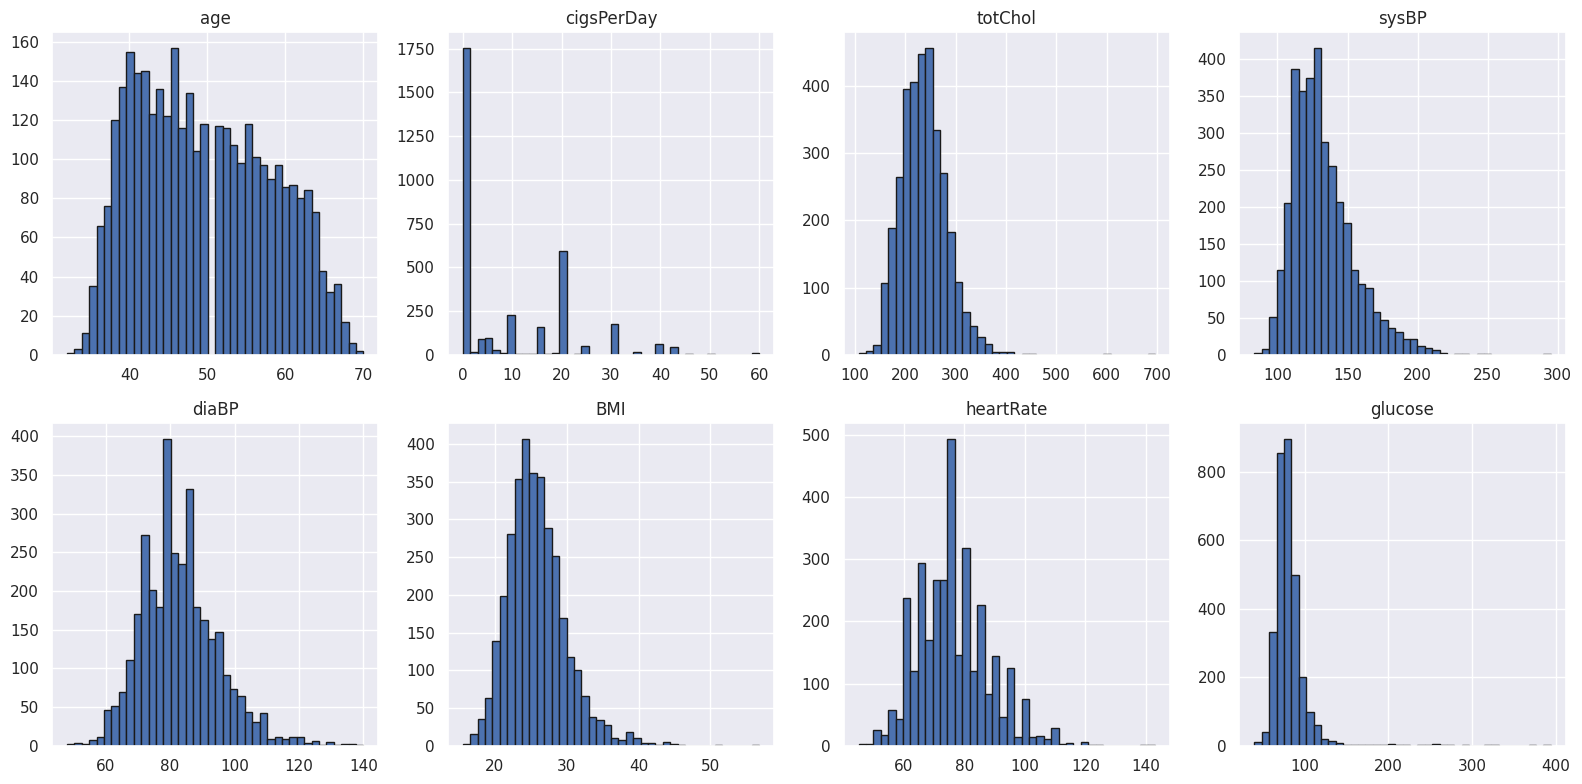

In [40]:
# List of continuous variables
continuous_vars = [
    "age", "cigsPerDay", "totChol",
    "sysBP", "diaBP", "BMI",
    "heartRate", "glucose"
]

# Plot all histograms at once in a 2×4 grid
axes = df[continuous_vars].hist(
    bins=40,
    figsize=(16, 8),
    layout=(2, 4),
    edgecolor="k"
)

plt.tight_layout()
plt.show()

#### 5.1.1 – Summary Statistics Table

In [41]:
stats = (
    df[continuous_vars]
    .agg(["mean", "median", "std", "skew"])
    .T
    .round(2)
    .rename_axis("feature")
    .reset_index()
)
stats  # Display the table

,feature,mean,median,std,skew
0,age,49.52,49.00,8.58,0.25
1,cigsPerDay,9.06,0.00,11.93,1.23
2,totChol,236.88,234.00,44.76,0.94
3,sysBP,132.39,128.00,22.12,1.14
4,diaBP,82.99,82.00,11.97,0.69
5,BMI,25.84,25.38,4.12,1.04
6,heartRate,76.00,75.00,11.93,0.66
7,glucose,82.00,78.00,23.75,6.23


**Insight:**
- **Skewness:**
  - glucose is highly right-skewed (skew ≈ 6.2), so a log or square-root transform could substantially improve its symmetry.  
  - cigsPerDay has a mild-to-moderate right skew (≈ 1.2), but it falls below the usual “strong skew” cutoff of 2.0.  
  - All other features (`age`, `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`) have skew < 1 and appear roughly symmetric.

- **Symmetry:**
  - age (skew ≈ 0.3), heartRate (≈ 0.7), and diaBP (≈ 0.7) are very close to symmetric.  
  - BMI (≈ 1.0), sysBP (≈ 1.1), and totChol (≈ 0.9) show only mild asymmetry.

- **Dispersion:**
  - totChol varies the most (SD ≈ 44.8), followed by glucose (≈ 23.8) and sysBP (≈ 22.1).  
  - cigsPerDay and heartRate both have SDs around 11.9, while age (≈ 8.6) and BMI (≈ 4.1) are comparatively tighter.

#### 5.1.2 – Boxplots for Outlier Detection

{'whiskers': [<matplotlib.lines.Line2D at 0x7a41c48a1f10>,
 'caps': [<matplotlib.lines.Line2D at 0x7a41c4dd0850>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7a41c488d390>],
 'medians': [<matplotlib.lines.Line2D at 0x7a41c4dd1b50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a41c4dd2450>],
 'means': []}

Text(0.5, 1.0, 'age')

{'whiskers': [<matplotlib.lines.Line2D at 0x7a41c4dd3510>,
 'caps': [<matplotlib.lines.Line2D at 0x7a41c4ddcd10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7a41c48f4bd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a41c4dde0d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a41c4ddebd0>],
 'means': []}

Text(0.5, 1.0, 'cigsPerDay')

{'whiskers': [<matplotlib.lines.Line2D at 0x7a41c4de4dd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a41c4de6010>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7a41c4de44d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a41c4de7490>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a41c4de7dd0>],
 'means': []}

...

Text(0.5, 1.0, 'BMI')

{'whiskers': [<matplotlib.lines.Line2D at 0x7a41c4c28c10>,
 'caps': [<matplotlib.lines.Line2D at 0x7a41c4c29f10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7a41c4e0e4d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a41c4c2b310>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a41c4c2bd10>],
 'means': []}

Text(0.5, 1.0, 'heartRate')

{'whiskers': [<matplotlib.lines.Line2D at 0x7a41c4c35b50>,
 'caps': [<matplotlib.lines.Line2D at 0x7a41c4c36e90>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7a41c4c351d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a41c4c3c190>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a41c4c3cb10>],
 'means': []}

Text(0.5, 1.0, 'glucose')

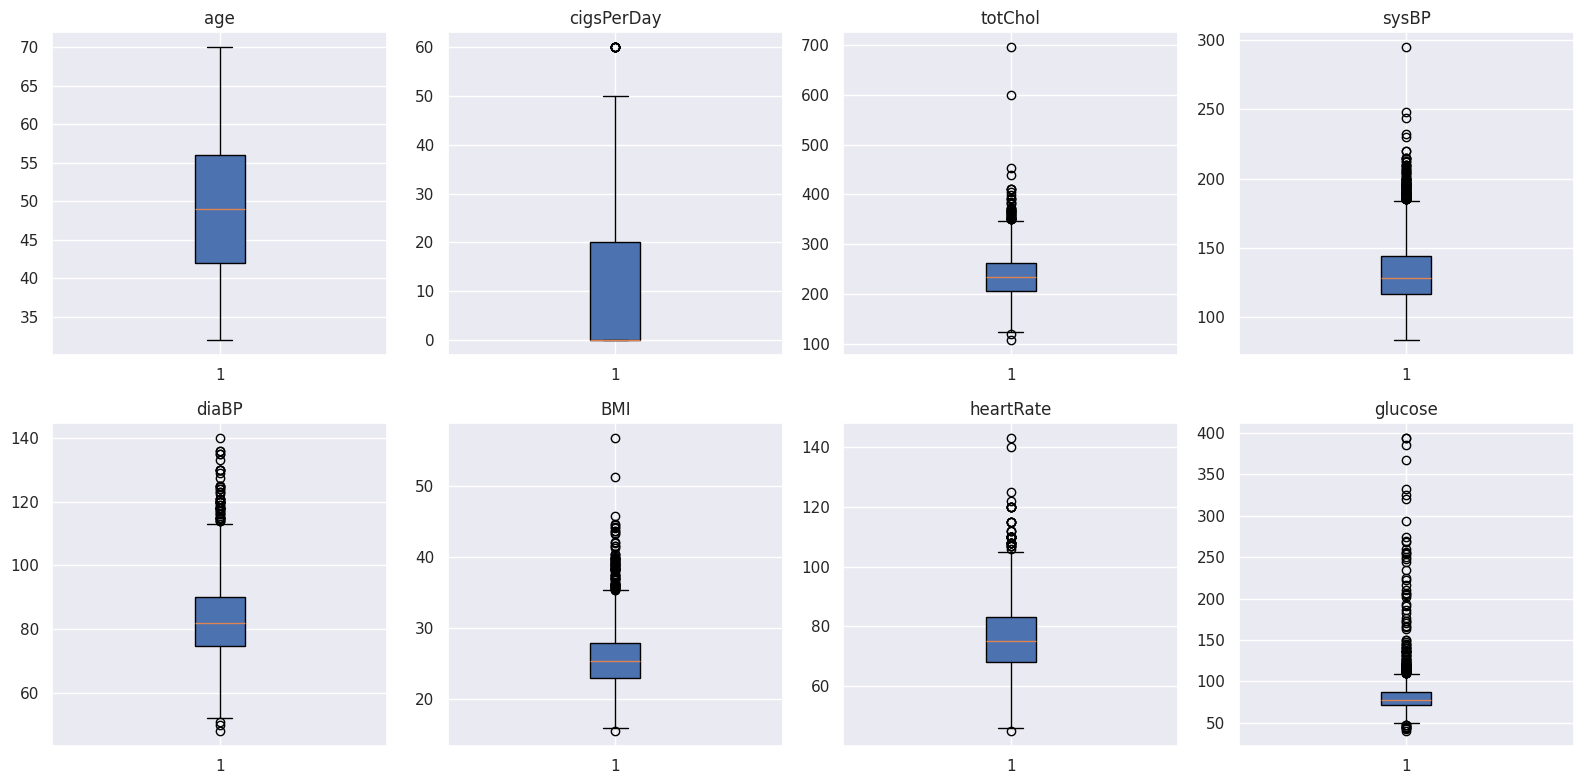

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), continuous_vars):
    ax.boxplot(df[col].dropna(), patch_artist=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:**
- Age is largely free of extreme values.
- cigsPerDay has many zeros (non-smokers) and a handful of very heavy smokers (up to ≈60 cigarettes/day).
- totChol and sysBP exhibit the most pronounced high-end outliers (totChol up to ≈700 mg/dL; sysBP up to ≈300 mmHg).
- diaBP, BMI, heartRate, and glucose each show some extreme values beyond their interquartile ranges.

### 5.2 - Binary / Categorical Features

1. Proportion Bar Grid: eight binary/ordinal variables plotted in a 2×4 grid, showing the percentage of each category rather than raw counts.  
2. Class Imbalance Insights: highlights that only ~11 % of patients develop CHD, guiding us to use stratified splits or class‐weighting later on.

By the end of this section, we will have:  
- A clear picture of each feature’s distribution and any quirks to address  
- A plan for imputation, transformation, and feature engineering  
- Concrete next steps for scaling and encoding before moving on to multivariate modeling  

Here we plot the proportion of each category for all eight binary/ordinal columns in a 2×4 grid (the last slot will be empty). Normalizing shows percent of patients in each class, making it easy to spot imbalances.


Text(0.5, 1.0, 'male')

Text(0, 0.5, 'Proportion')

Text(0.0, 0.5872861356932153, '0.58')

Text(1.0, 0.43271386430678466, '0.42')

Text(0.5, 1.0, 'education')

...

Text(1.0, 0.03507374631268437, '0.03')

Text(0.5, 1.0, 'CHD')

Text(0, 0.5, 'Proportion')

Text(0.0, 0.8566076696165191, '0.85')

Text(1.0, 0.16339233038348083, '0.15')

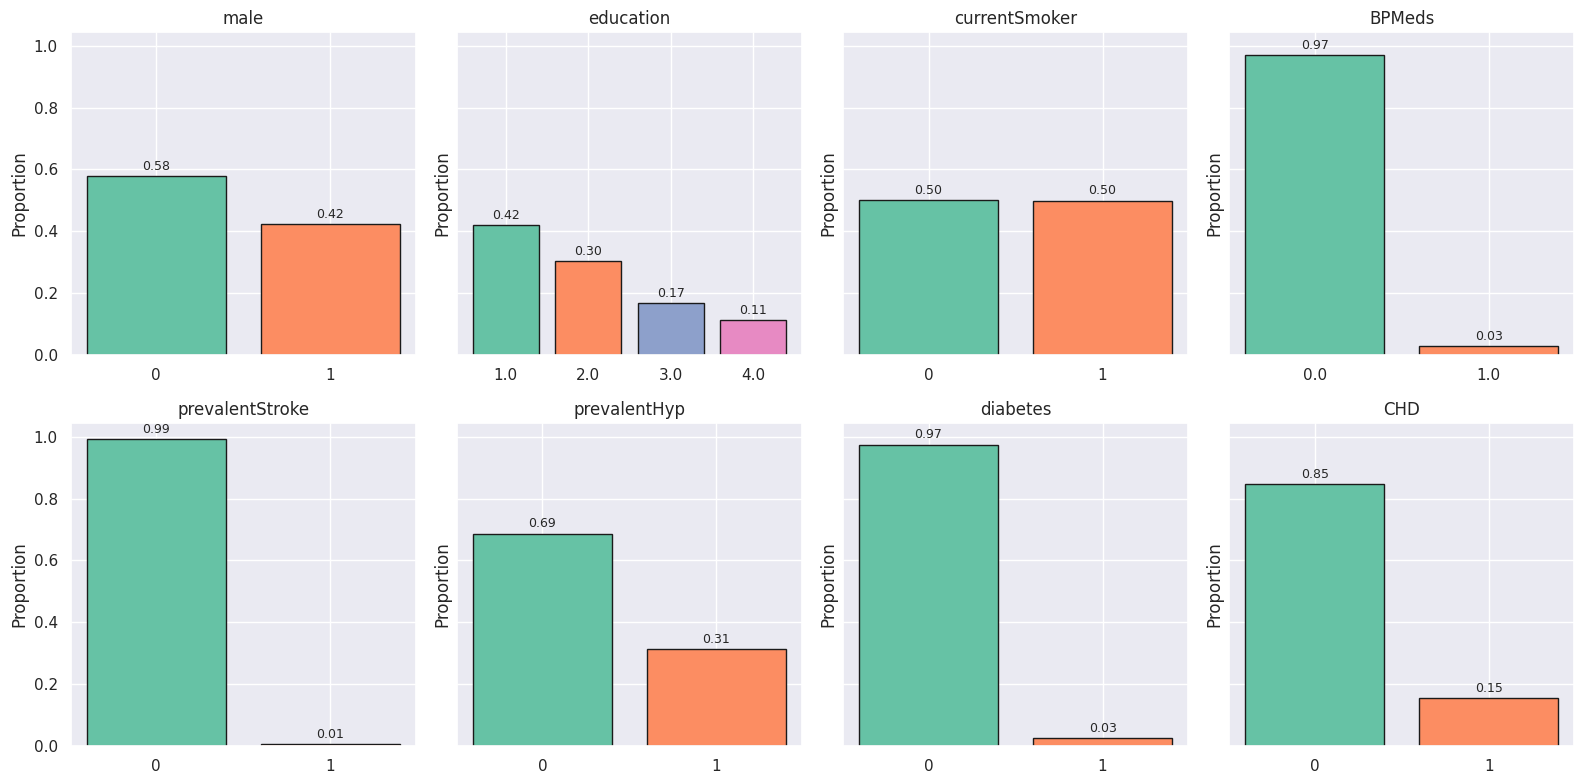

In [43]:
cat_cols = [
    "male", "education", "currentSmoker", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes", "CHD"
]

# Compute normalized counts (proportions)
props = {
    col: df[col].value_counts(normalize=True).sort_index()
    for col in cat_cols
}

# Create a 2×4 grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = props[col]
    cats = counts.index.astype(str)
    vals = counts.values

    # one distinct color per category
    palette = sns.color_palette("Set2", len(cats))

    bars = ax.bar(cats, vals, color=palette, edgecolor="k")
    ax.set_title(col)
    ax.set_ylabel("Proportion")

    # label each bar with its proportion
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.01,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

**Insight:**
- The cohort is slightly female-skewed (~58% female vs. 42% male).  
- Education levels drop off quickly: ~42% at level 1, 30% at level 2, then only 17% and 11% at levels 3 and 4.  
- Current smoking is split 50/50, making it a key risk factor to consider.  
- Very few patients are on blood-pressure meds (3%), have had a stroke (~1%), or have diabetes ( ~3%).
- Prevalent hypertension is more common (~31%).  
- Only ~15% of patients have CHD, indicating a moderate class imbalance in the target.  

#### 5.2.1 - Explanation of the 2×4 Categorical Proportion Plot Above

1. **Selecting Variables**  
   We list eight categorical columns (`cat_cols`) that we want to inspect, each representing a binary (e.g. `male`, `diabetes`) or ordinal (e.g. `education`) feature.

2. **Computing Proportions**  
   Using `value_counts(normalize=True)`, we convert raw counts into proportions (fractions of the total), which makes it easy to compare categories across groups of different sizes.  
   We sort by index so that the bars always appear in logical order (e.g. 0 then 1).

3. **Laying Out the Figure**  
   - We create a figure with `plt.subplots(2, 4, ...)` to organize eight plots in two rows of four.  
   - `sharey=True` ensures all subplots use the same y-axis scale, enabling direct visual comparison of proportions across different variables.

4. **Drawing Each Bar Chart**  
   - For each subplot, we extract the category labels (`cats`) and their proportions (`vals`).  
   - We choose a distinct color for each bar using Seaborn’s `Set2` palette to help the eye differentiate categories at a glance.  
   - We add black edges (`edgecolor="k"`) to make the bars stand out against the background.

5. **Annotating for Clarity**  
   - Titles: Every subplot is titled with its column name for quick identification.  
   - Y-axis label: “Proportion” is set once per chart to remind the reader what the bar heights represent.  
   - Data labels: We loop over bars and place the exact proportion (formatted to two decimal places) just above each bar, so the viewer doesn’t need to eyeball precise values.

6. **Finishing Touches**  
   - `plt.tight_layout()` automatically adjusts spacing so titles, labels, and bars don’t overlap.  
   - `plt.show()` renders the complete figure in one cohesive display.

By structuring the code this way, we minimize repetition (compute proportions once), maximize comparability (shared y-axis, consistent layout), and enhance readability (distinct colors plus value annotations), demonstrating a clear understanding of both the mechanics and the rationale of exploratory data visualization.

# 6 - Bivariate Relationships

To explore the relationship between cardiovascular risk factors and Coronary Heart Disease (CHD) outcomes, we generated both boxplots (for continuous variables) and grouped bar plots (for categorical variables).

## 6.1 - Continuous vs. Outcome


To better understand how each continuous variable might relate to the presence of coronary heart disease (CHD), we created a series of boxplots.

These visualizations make it easy to compare how values are distributed between patients who did and did not develop CHD over a 10-year period.

With boxplots, we can quickly spot:
- Differences in **medians** (the central line inside each box)
- The **spread** of values (how wide or narrow the box is)
- Potential **outliers** (the dots outside the whiskers)

This helps us see which variables might be helpful for predicting CHD later in the modeling phase.


For this we used a loop built with "for .. in" in this way the cycle will keep going until all the variables on the entire list of numerical features, num_cols, are used.

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='age'>

Text(0.5, 1.0, 'Boxplot of age vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'age')

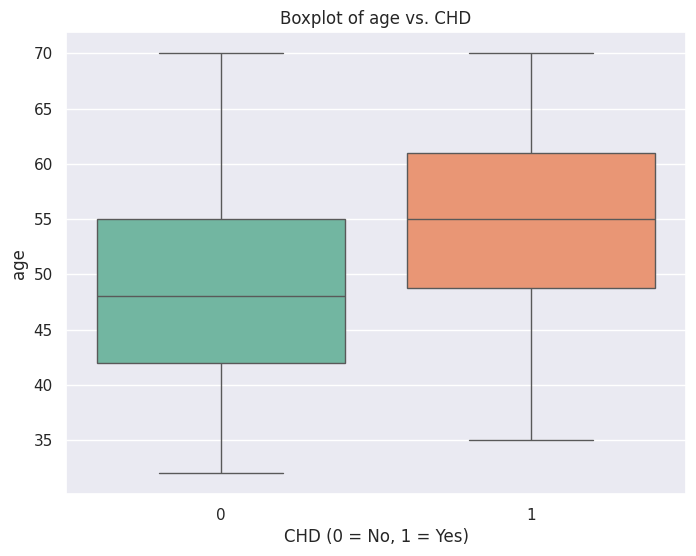

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='cigsPerDay'>

Text(0.5, 1.0, 'Boxplot of cigsPerDay vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'cigsPerDay')

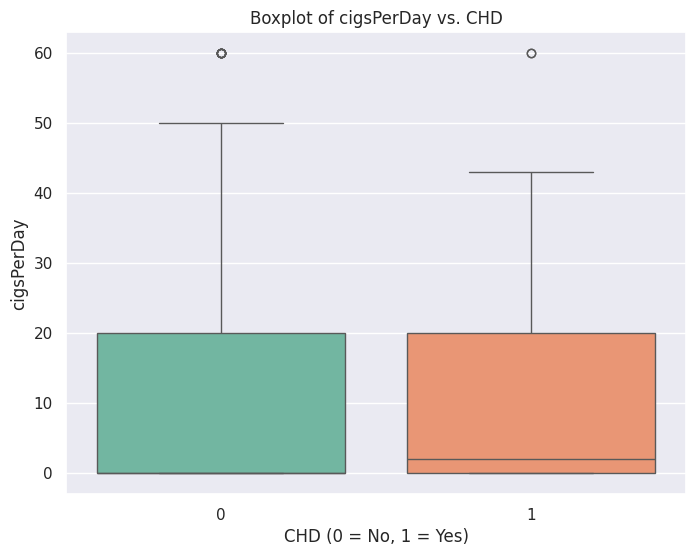

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='totChol'>

Text(0.5, 1.0, 'Boxplot of totChol vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'totChol')

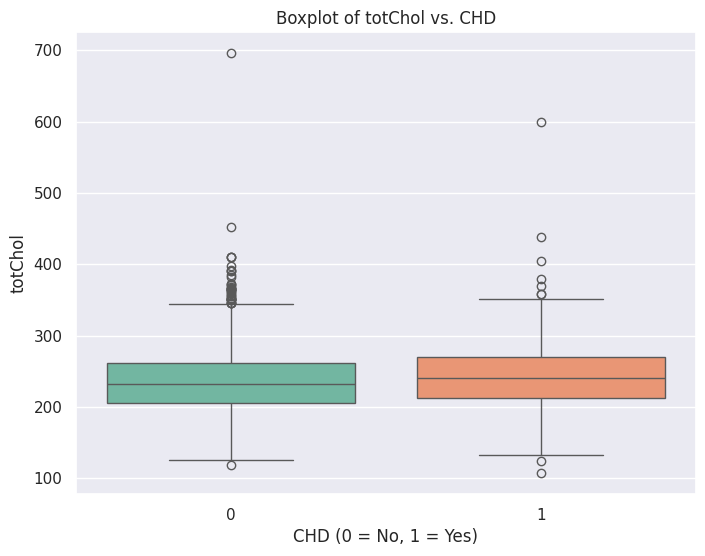

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='sysBP'>

Text(0.5, 1.0, 'Boxplot of sysBP vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'sysBP')

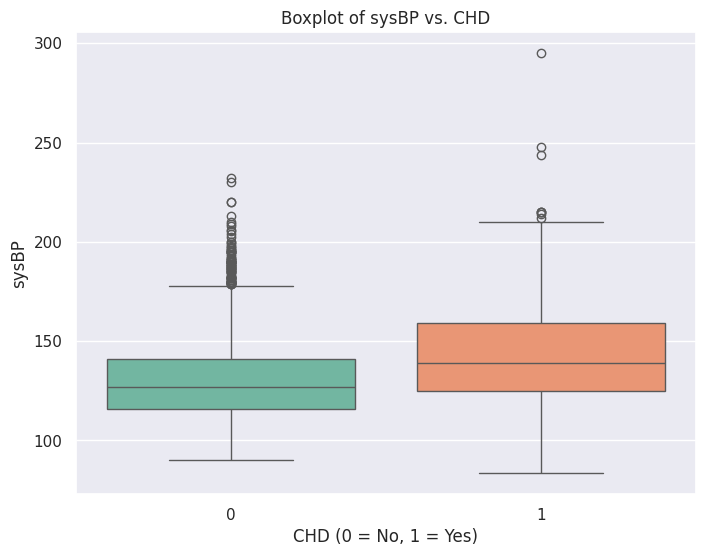

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='diaBP'>

Text(0.5, 1.0, 'Boxplot of diaBP vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'diaBP')

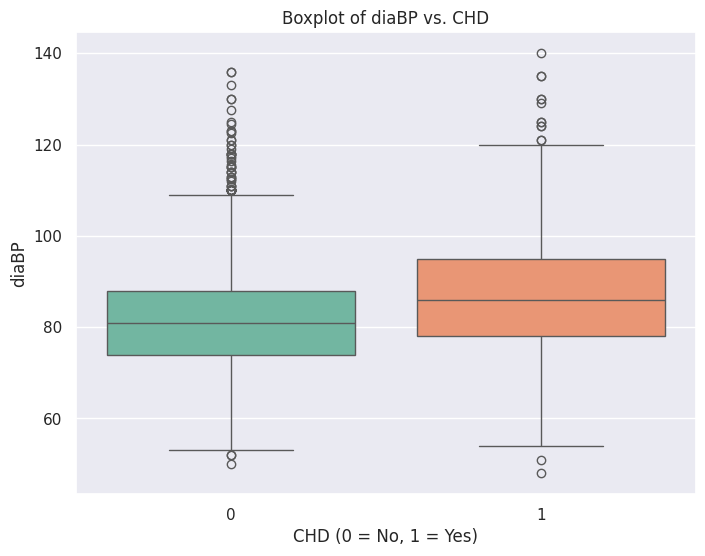

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='BMI'>

Text(0.5, 1.0, 'Boxplot of BMI vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'BMI')

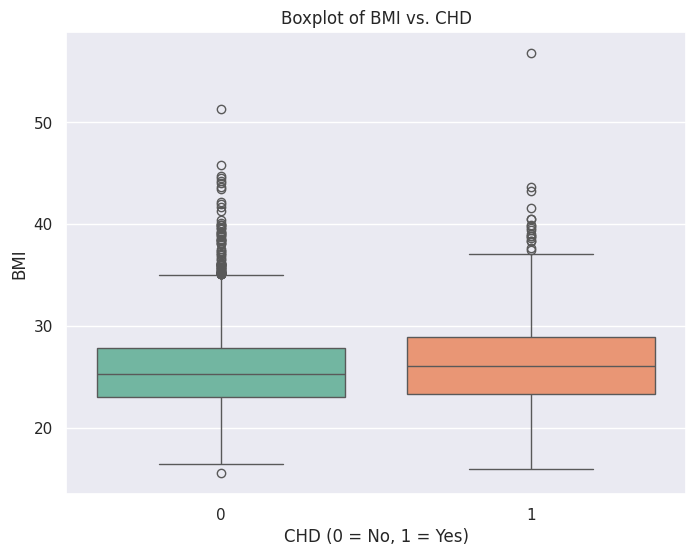

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='heartRate'>

Text(0.5, 1.0, 'Boxplot of heartRate vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'heartRate')

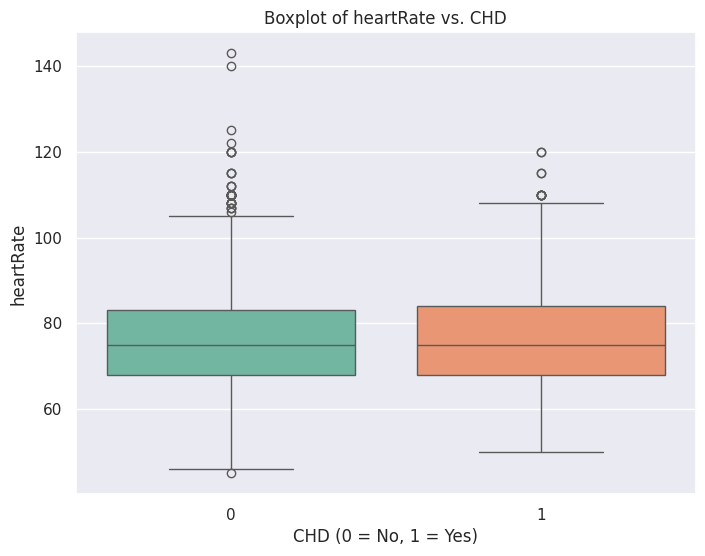

<Figure size 800x600 with 0 Axes>

/tmp/ipython-input-44-1324524971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHD', y=col, data=df, palette='Set2')


<Axes: xlabel='CHD', ylabel='glucose'>

Text(0.5, 1.0, 'Boxplot of glucose vs. CHD')

Text(0.5, 0, 'CHD (0 = No, 1 = Yes)')

Text(0, 0.5, 'glucose')

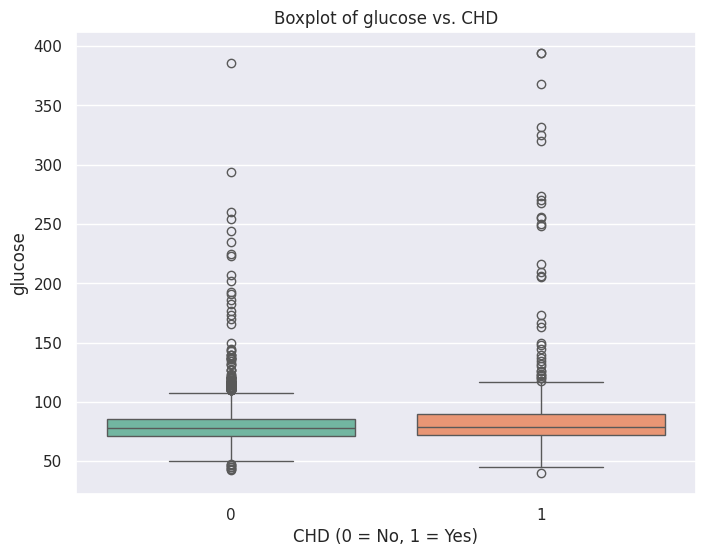

In [44]:
num_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='CHD', y=col, data=df, palette='Set2')
    plt.title(f'Boxplot of {col} vs. CHD')
    plt.xlabel('CHD (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()


## 6.2 - Categorical vs. Outcome

Grouped Bar Charts are ideal to check the frequency of one outcome when filtered by one variable.

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='male', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by male')

Text(0.5, 0, 'male')

Text(0, 0.5, 'Number of Patients')

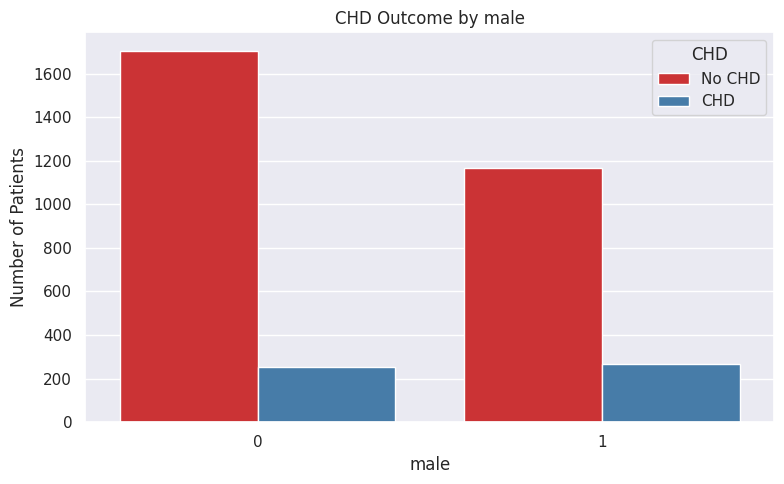

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='education', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by education')

Text(0.5, 0, 'education')

Text(0, 0.5, 'Number of Patients')

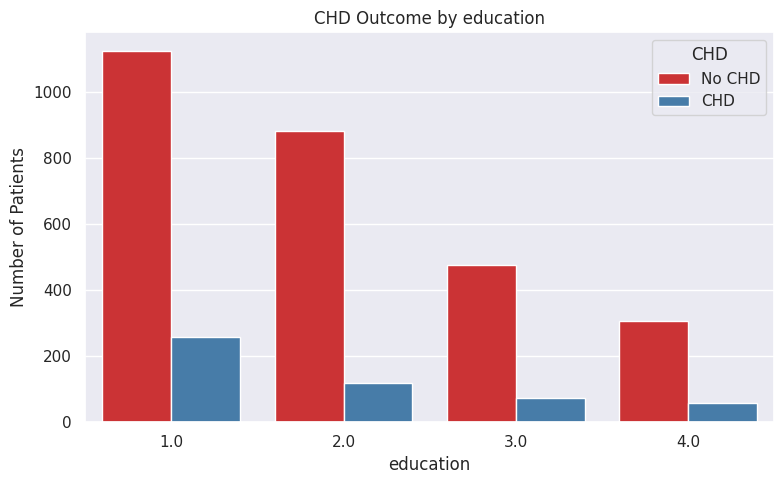

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='currentSmoker', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by currentSmoker')

Text(0.5, 0, 'currentSmoker')

Text(0, 0.5, 'Number of Patients')

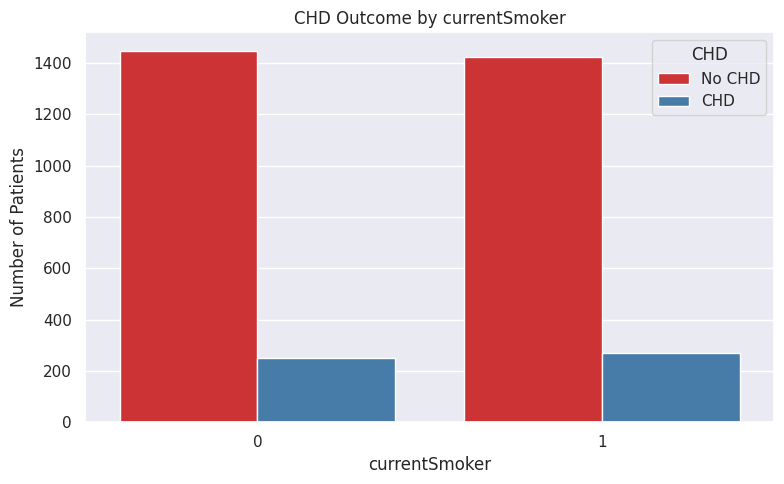

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='BPMeds', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by BPMeds')

Text(0.5, 0, 'BPMeds')

Text(0, 0.5, 'Number of Patients')

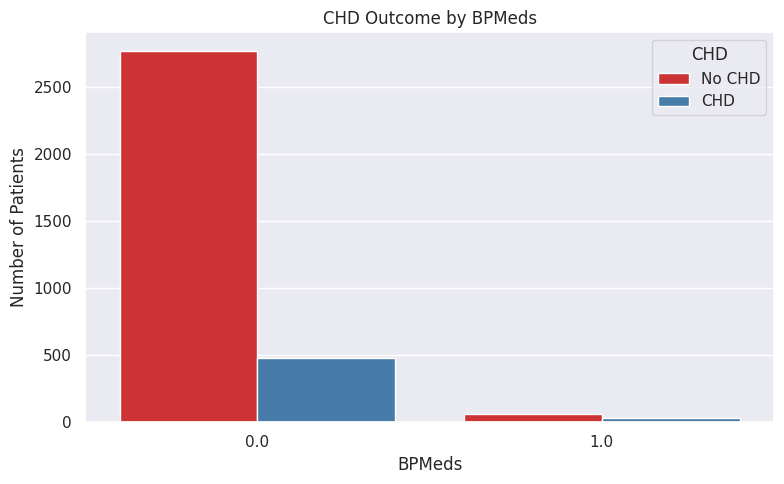

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='prevalentStroke', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by prevalentStroke')

Text(0.5, 0, 'prevalentStroke')

Text(0, 0.5, 'Number of Patients')

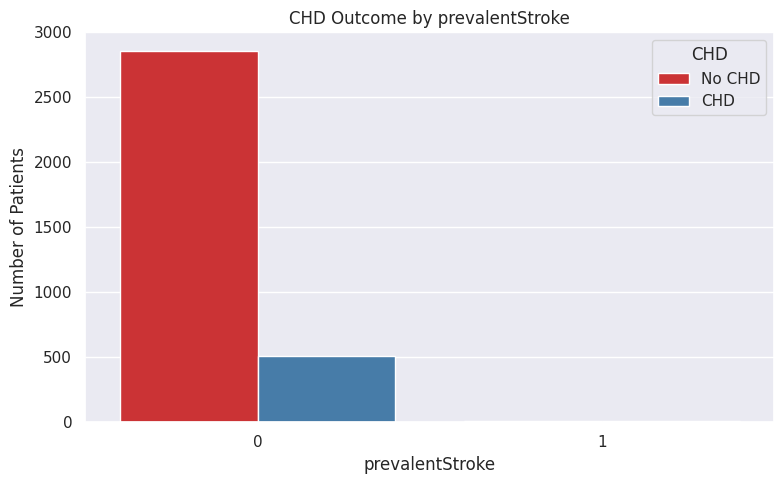

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='prevalentHyp', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by prevalentHyp')

Text(0.5, 0, 'prevalentHyp')

Text(0, 0.5, 'Number of Patients')

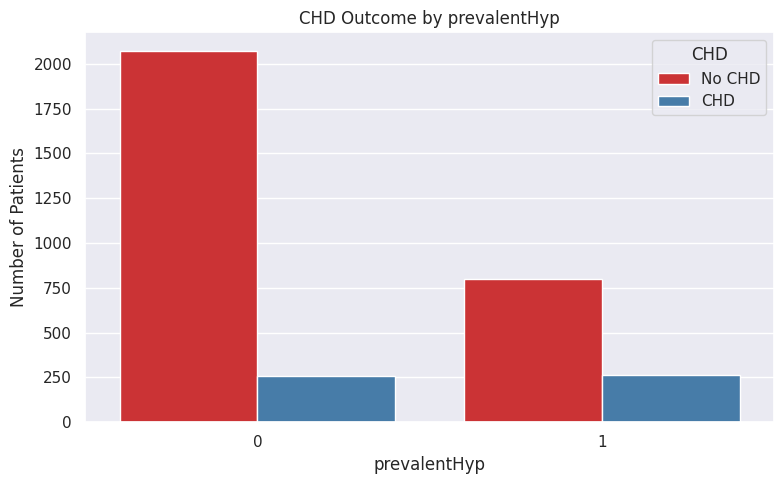

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='diabetes', ylabel='count'>

Text(0.5, 1.0, 'CHD Outcome by diabetes')

Text(0.5, 0, 'diabetes')

Text(0, 0.5, 'Number of Patients')

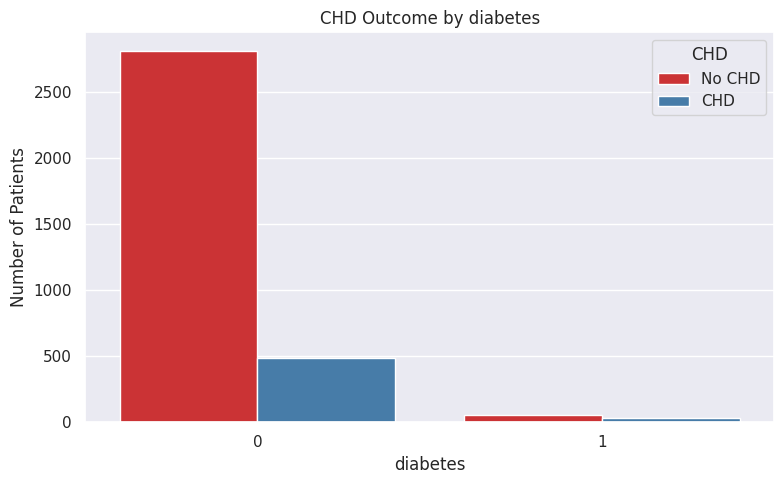

In [45]:
discrete_cols = ["male", "education", "currentSmoker", "BPMeds",
                 "prevalentStroke", "prevalentHyp", "diabetes"]

for col in discrete_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue="CHD", data=df, palette="Set1")

    plt.title(f'CHD Outcome by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Patients')
    plt.legend(title='CHD', labels=['No CHD', 'CHD'])
    plt.tight_layout()
    plt.show()




To compare the number of CHD vs. non-CHD cases within each category, we used grouped bar plots. These show how the frequency of CHD varies across groups — for example, whether men have more CHD cases than women, or whether smokers show different patterns compared to non-smokers.

Each bar represents the number of patients in that category, grouped by CHD outcome.


# 7 - Correlation Matrix

We also decided to generate a Heat Map with the values of the Pearsons correlation coefficients between all numeric variables and also added our targeted variable, CHD, to the list eventhough it is a boolean variable. To do this we used the code:

In [46]:
corr = df[num_cols + ["CHD"]].corr

We decided and setted up the figure size, 10 inches wide and 8 inches tall:

In [47]:
# plt.figure(figsize=(10, 8))


Then, with the help of the Seaborn Library Import, sns, we designed and created an heat map.

In [48]:
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

In [49]:
## sns.heatmap() draws a color-coded matrix (heatmap) based on the correlation values in corr.

## annot=True displays the numeric correlation coefficients inside each cell.

## fmt=".2f" formats these numbers to two decimal places.

## cmap="coolwarm" uses a color gradient where blues indicate negative correlations, reds indicate positive correlations, and white or neutral colors indicate values near zero.

## center=0 centers the color gradient on zero, so negative and positive correlations are equally highlighted.

Added a plot title:

In [50]:
# plt.title("Feature Correlation Heatmap")

And adjusted the layout:

In [51]:
# plt.tight_layout()
# plt.show()


All joined together:

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Correlation Heatmap')

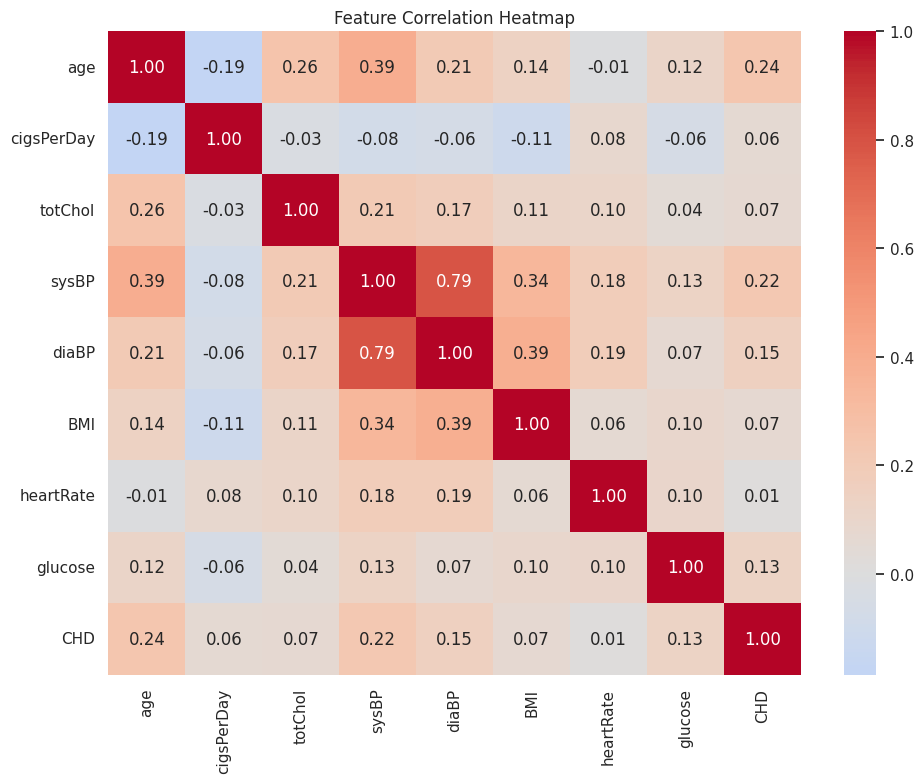

In [52]:
# Compute correlations including numeric features and the binary target 'CHD'
corr = df[num_cols + ["CHD"]].corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# 8 - Key Takeaways

## 8 – Key Takeaways

1. **Age & Gender**  
   - Individuals who develop 10-year CHD are, on average, older; the risk increases steadily with age.  
   - Males have a higher proportion of CHD events than females, consistent with known cardiovascular risk profiles.

2. **Blood Pressure**  
   - Both systolic and diastolic blood pressure distributions are shifted higher in the CHD group, with more extreme outliers.  
   - Hypertension prevalence is markedly greater among those who experience CHD.

3. **Cholesterol & Glucose**  
   - Total cholesterol exhibits moderate right skew but higher mean/median in the CHD subset.  
   - Glucose is highly skewed overall; elevated glucose levels (and diabetes diagnosis) correlate strongly with increased CHD risk.

4. **Smoking Behavior**  
   - Current smokers not only have higher CHD incidence but also smoke more cigarettes per day, reinforcing smoking as a critical modifiable risk factor.

5. **Diabetes & Medication**  
   - Diabetes prevalence is notably higher among CHD cases.  
   - Use of blood pressure medication (BPMeds) is also more common, reflecting comorbid management needs.

6. **Body Mass Index & Heart Rate**  
   - BMI shows only a slight upward shift in the CHD group, suggesting it’s a weaker standalone predictor but still relevant in multivariate context.  
   - Resting heart rate is marginally higher in those with CHD history.

7. **Inter-Feature Correlations**  
   - Strongest correlations occur among blood pressure measures and between BMI and glucose, which may inform feature engineering (e.g., combining related predictors).

8. **Data Quality & Next Steps**  
   - Missingness was low after dropping incomplete rows, but consider imputing or flagging missing data in future iterations.  
   - Transforming skewed features (e.g., log-transforming glucose) and addressing outliers will likely improve model stability and interpretability.